#Deep Tabular Neural Network

This model learns patterns from a dataset table by using multiple neural network layers. The neural network will consist of multiple fully connected layers that learn nonlinear relationships between restaurant characteristics and the likelihood of closure. This will allow us to integrate mixed data types to properly capture how our basic stats interact with each other.

### 1. Load dataset

In [1]:
!pip install pytorch-tabnet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.5 MB/s eta 0:00:00


In [2]:
path3 = '/content/drive/MyDrive/Data Mining/Project/model_dataset.csv'

df = pd.read_csv(path3)

print(df.shape)
print(df.head())

(20000, 40)
                      name          city state postal_code   latitude  \
0              Double Knot  Philadelphia    PA       19107  39.949699   
1    Hên Vietnamese Eatery   Cherry Hill    NJ       08003  39.896071   
2  Gourmet Seafood & Grill      Skippack    PA       19473  40.227668   
3           Clear Sky Cafe    Clearwater    FL       33767  27.981960   
4         Coffee House Too  Philadelphia    PA       19125  39.976728   

   longitude  business_stars  RestaurantsPriceRange2  NoiseLevel  \
0 -75.162185             4.5                     3.0         2.0   
1 -74.949167             4.5                     2.0         2.0   
2 -75.404260             3.5                     2.0         1.0   
3 -82.827297             4.5                     2.0         2.0   
4 -75.123718             4.5                     2.0         2.0   

   parking_options_count  ...  location_cluster  num_categories  \
0                    1.0  ...                11               6   
1     

### 2. Basic Checks

In [3]:
print(df.columns.tolist())
print(df["target"].value_counts(dropna=False))
print(df["target"].value_counts(normalize=True, dropna=False))

['name', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'business_stars', 'RestaurantsPriceRange2', 'NoiseLevel', 'parking_options_count', 'meal_options_count', 'ambience_score', 'music_options_count', 'best_nights_count', 'is_full_service', 'is_bar_style', 'is_family_friendly', 'is_takeout_friendly', 'is_date_spot', 'primary_category', 'hours_open_per_week', 'days_open', 'avg_hours_per_day', 'open_late', 'open_early', 'weekend_hours', 'nearest_dist', 'num_neighbors_1km', 'same_cuisine_neighbors', 'avg_neighbor_rating', 'location_cluster', 'num_categories', 'has_nightlife', 'has_fast_food', 'has_breakfast', 'has_seafood', 'has_asian', 'has_mexican', 'has_italian', 'target']
target
0    13991
1     6009
Name: count, dtype: int64
target
0    0.69955
1    0.30045
Name: proportion, dtype: float64


### 3. Define features and target

In [4]:
X = df.drop(columns=["target"])
y = df["target"].astype(int)

# TabNet works best with numeric input
X = X.select_dtypes(include=[np.number]).copy()


### 4. Handle missing values

In [5]:
# Drop highly missing columns (>70% missing)
missing_ratio = X.isnull().mean()
high_missing = missing_ratio[missing_ratio > 0.7].index

print("Dropping high-missing columns:", list(high_missing))

X = X.drop(columns=high_missing)

# Fill remaining numeric columns
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna("Unknown")

print("Remaining missing:", X.isnull().sum().sum())

Dropping high-missing columns: []
Remaining missing: 0


### 5. Train-Test Split

In [6]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

### 6. Scale features

In [8]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("X shape:", X_train.shape)
print("y shape:", y.shape)
print("Target distribution:\n", pd.Series(y).value_counts())

X shape: (12800, 34)
y shape: (20000,)
Target distribution:
 target
0    13991
1     6009
Name: count, dtype: int64


### 7. Class weights

In [9]:
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
weights_dict = {cls: weight for cls, weight in zip(classes, class_weights)}
sample_weights = np.array([weights_dict[label] for label in y_train])


### 8. TabNet Model

In [10]:
tabnet_model = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=4,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_params=dict(lr=2e-2),
    mask_type="entmax",
    seed=42,
    verbose=1
)

# -------------------------
# Train
# -------------------------
tabnet_model.fit(
    X_train=X_train,
    y_train=y_train.values,
    eval_set=[(X_val, y_val.values)],
    eval_name=["val"],
    eval_metric=["auc"],
    max_epochs=200,
    patience=30,
    batch_size=256,
    virtual_batch_size=128,
    num_workers=0,
    weights=sample_weights,
    drop_last=False
)


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.43895 | val_auc: 0.88588 |  0:00:06s
epoch 1  | loss: 0.30328 | val_auc: 0.92354 |  0:00:10s
epoch 2  | loss: 0.26129 | val_auc: 0.93649 |  0:00:13s
epoch 3  | loss: 0.27437 | val_auc: 0.94317 |  0:00:16s
epoch 4  | loss: 0.25355 | val_auc: 0.94563 |  0:00:18s
epoch 5  | loss: 0.24979 | val_auc: 0.95306 |  0:00:20s
epoch 6  | loss: 0.24435 | val_auc: 0.95798 |  0:00:22s
epoch 7  | loss: 0.23484 | val_auc: 0.96042 |  0:00:23s
epoch 8  | loss: 0.24355 | val_auc: 0.96263 |  0:00:25s
epoch 9  | loss: 0.22986 | val_auc: 0.96432 |  0:00:27s
epoch 10 | loss: 0.21822 | val_auc: 0.96583 |  0:00:29s
epoch 11 | loss: 0.21882 | val_auc: 0.96144 |  0:00:32s
epoch 12 | loss: 0.22149 | val_auc: 0.96564 |  0:00:34s
epoch 13 | loss: 0.2101  | val_auc: 0.96552 |  0:00:35s
epoch 14 | loss: 0.20475 | val_auc: 0.9668  |  0:00:37s
epoch 15 | loss: 0.21043 | val_auc: 0.96553 |  0:00:39s
epoch 16 | loss: 0.21026 | val_auc: 0.96641 |  0:00:41s
epoch 17 | loss: 0.19642 | val_auc: 0.96887 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


### 9. Evaluate Model

In [11]:
y_pred = tabnet_model.predict(X_test)
y_proba = tabnet_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Accuracy: 0.9465
ROC-AUC: 0.9815450839023357
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2798
           1       0.91      0.91      0.91      1202

    accuracy                           0.95      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.95      0.95      0.95      4000



### 10 . Hypertuning

In [12]:
# 3. final model
final_model = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-3),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={"step_size": 10, "gamma": 0.9},
    mask_type="entmax",
    verbose=1
)

# 4. train using validation set only
final_model.fit(
    X_train, y_train.values,
    eval_set=[(X_val, y_val.values)],
    eval_name=["val"],
    eval_metric=["auc"],
    max_epochs=200,
    patience=30,
    batch_size=256,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.82535 | val_auc: 0.56928 |  0:00:01s
epoch 1  | loss: 0.62687 | val_auc: 0.71447 |  0:00:02s
epoch 2  | loss: 0.54358 | val_auc: 0.79783 |  0:00:04s
epoch 3  | loss: 0.47566 | val_auc: 0.84819 |  0:00:05s
epoch 4  | loss: 0.42419 | val_auc: 0.86986 |  0:00:07s
epoch 5  | loss: 0.38395 | val_auc: 0.88142 |  0:00:09s
epoch 6  | loss: 0.36504 | val_auc: 0.89276 |  0:00:10s
epoch 7  | loss: 0.34014 | val_auc: 0.90527 |  0:00:11s
epoch 8  | loss: 0.33033 | val_auc: 0.9172  |  0:00:13s
epoch 9  | loss: 0.30784 | val_auc: 0.92654 |  0:00:14s
epoch 10 | loss: 0.29963 | val_auc: 0.93308 |  0:00:15s
epoch 11 | loss: 0.2866  | val_auc: 0.93806 |  0:00:17s
epoch 12 | loss: 0.27945 | val_auc: 0.94274 |  0:00:18s
epoch 13 | loss: 0.27119 | val_auc: 0.9459  |  0:00:20s
epoch 14 | loss: 0.26496 | val_auc: 0.94852 |  0:00:22s
epoch 15 | loss: 0.2613  | val_auc: 0.95073 |  0:00:23s
epoch 16 | loss: 0.25745 | val_auc: 0.9518  |  0:00:25s
epoch 17 | loss: 0.25314 | val_auc: 0.95292 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [13]:
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("Test AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.923
Test AUC: 0.9729849226747416

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.95      0.95      2798
           1       0.89      0.85      0.87      1202

    accuracy                           0.92      4000
   macro avg       0.91      0.90      0.91      4000
weighted avg       0.92      0.92      0.92      4000



### 11. Top features

In [14]:
feature_names = X.columns.tolist()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": final_model.feature_importances_
}).sort_values(by="importance", ascending=False)


print("\nTop Features:")
print(feature_importance.head(15))

feature_importance.to_csv("/content/drive/MyDrive/Data Mining/Project/tabnet_feature_importance.csv", index=False)


Top Features:
                   feature  importance
2           business_stars    0.147430
23  same_cuisine_neighbors    0.104444
7           ambience_score    0.063523
16               days_open    0.056098
15     hours_open_per_week    0.051747
22       num_neighbors_1km    0.050982
25        location_cluster    0.046778
6       meal_options_count    0.043524
5    parking_options_count    0.039431
24     avg_neighbor_rating    0.034508
11            is_bar_style    0.030930
3   RestaurantsPriceRange2    0.028268
17       avg_hours_per_day    0.025092
1                longitude    0.022089
21            nearest_dist    0.016424


Confusion Matrix Plot

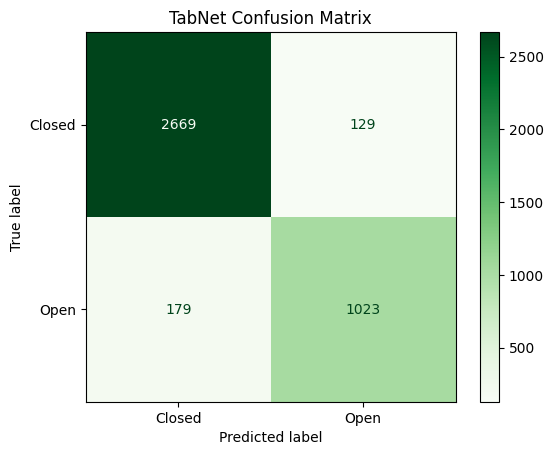

In [15]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Closed", "Open"]
)

disp.plot(cmap="Greens")
plt.title("TabNet Confusion Matrix")
plt.show()

ROC Curve plot

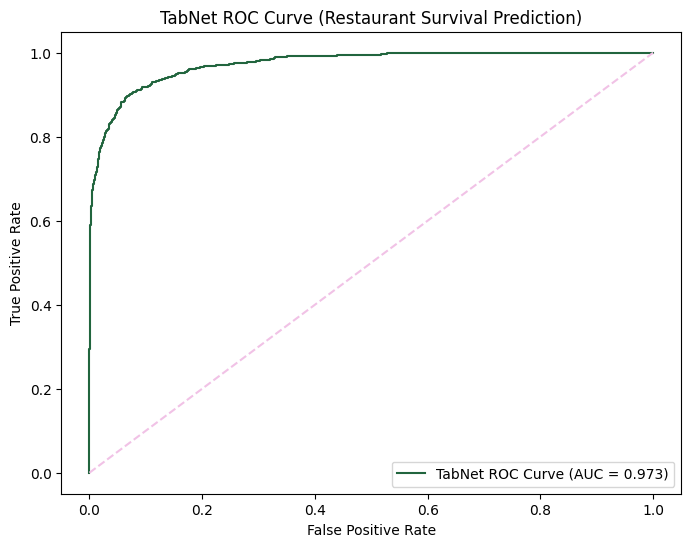

In [16]:
y_prob = final_model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr, tpr,
    color="#21653e",
    label=f"TabNet ROC Curve (AUC = {roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="#f1c2e6")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("TabNet ROC Curve (Restaurant Survival Prediction)")
plt.legend()
plt.show()

Top 15 Feature Importance Plot

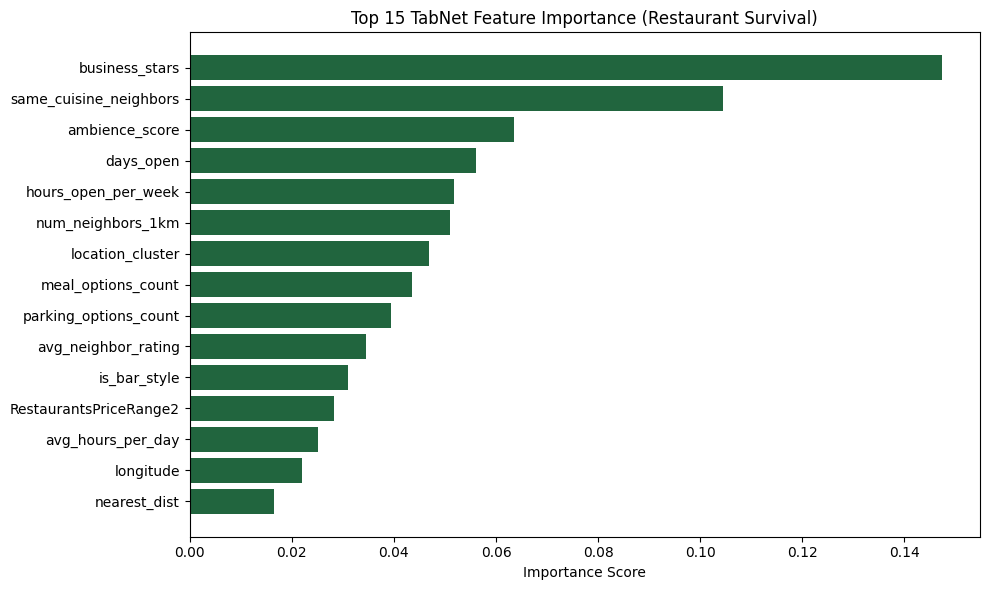

In [17]:
feature_importance_series = pd.Series(
    final_model.feature_importances_,
    index=X.columns
)

top15 = feature_importance_series.sort_values(ascending=False).head(15).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top15.index, top15.values, color='#21653e')

plt.xlabel("Importance Score")
plt.title("Top 15 TabNet Feature Importance (Restaurant Survival)")

plt.tight_layout()
plt.show()

#Save

In [18]:
import joblib
import json

final_model.save_model("tabnet_final_model")
joblib.dump(scaler, "tabnet_scaler.pkl")

with open("tabnet_feature_columns.json", "w") as f:
    json.dump(list(X_train_full.columns), f)

Successfully saved model at tabnet_final_model.zip
